## 1.Loding Data

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
mat=pd.read_csv("matches.csv")

In [96]:
dev=pd.read_csv("deliveries.csv")

## 2.analyze data set

In [97]:
mat.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [98]:
mat.shape

(1095, 20)

In [99]:
mat.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [100]:
mat.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [101]:
# city with most matches won
mat.groupby(["city"]).agg({"winner":["count"]}).max()


winner  count    173
dtype: int64

In [102]:
mat.groupby(["city"]).agg({"winner":["count"]}).sort_values(ascending=False,by=("winner","count")).head(1)

,winner
,count
city,
Mumbai,173


In [103]:
# team that won most matches
mat["winner"].value_counts().head(1)

winner
Mumbai Indians    144
Name: count, dtype: int64

In [104]:
# player who won most of man of the match awards
mat["player_of_match"].value_counts().head(1)

player_of_match
AB de Villiers    25
Name: count, dtype: int64

In [105]:
# most frequent umpire 1
mat["umpire1"].value_counts().head(1)

umpire1
AK Chaudhary    115
Name: count, dtype: int64

In [106]:
# most frequent umpire 2

mat["umpire2"].value_counts().head(1)

umpire2
S Ravi    83
Name: count, dtype: int64

In [107]:
mat.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1095.0,904828.319635,367740.242299,335982.0,548331.5,980961.0,1254062.5,1426312.0
result_margin,1076.0,17.259294,21.787444,1.0,6.0,8.0,20.0,146.0
target_runs,1092.0,165.684066,33.427048,43.0,146.0,166.0,187.0,288.0
target_overs,1092.0,19.759341,1.581108,5.0,20.0,20.0,20.0,20.0


In [108]:
dev.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [109]:
dev.shape

(260920, 17)

In [110]:
dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

## 3. visualizing the data

<Axes: xlabel='winner'>

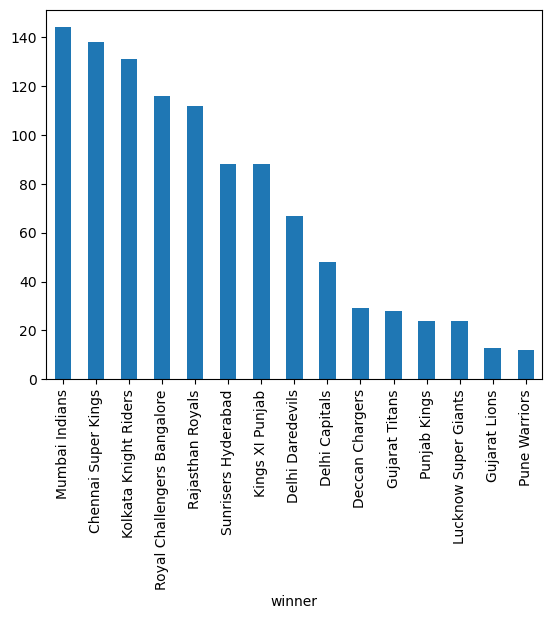

In [111]:
mat["winner"].value_counts().head(15).plot(kind="bar")

In [112]:
mat.winner.unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Daredevils',
       'Royal Challengers Bangalore', 'Rajasthan Royals',
       'Kings XI Punjab', 'Deccan Chargers', 'Mumbai Indians',
       'Pune Warriors', 'Kochi Tuskers Kerala', nan,
       'Sunrisers Hyderabad', 'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru'], dtype=object)

<Axes: xlabel='player_of_match'>

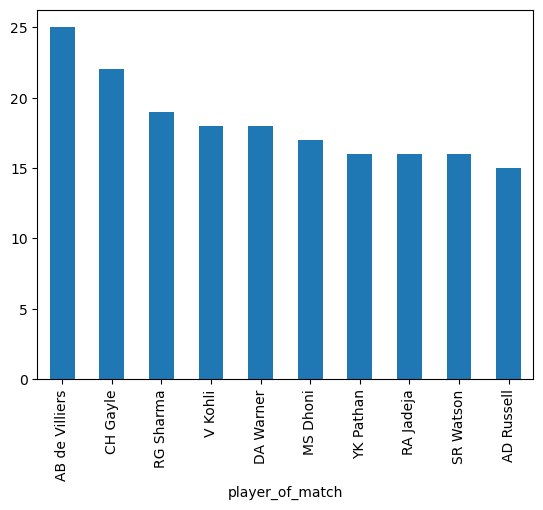

In [113]:
mat["player_of_match"].value_counts().head(10).plot(kind="bar")

<Axes: xlabel='toss_winner'>

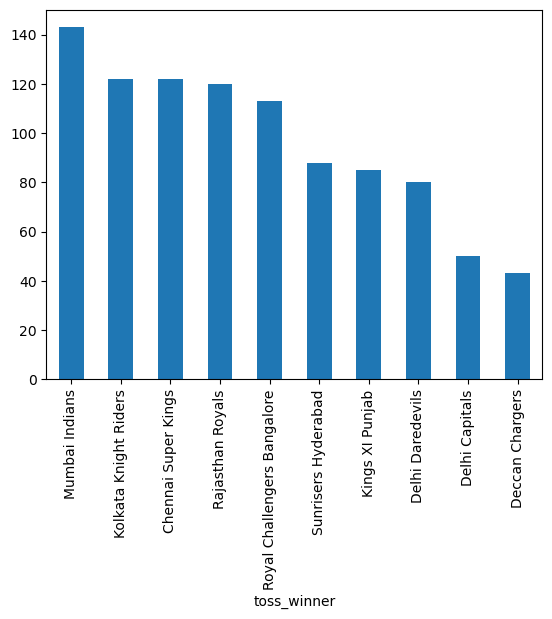

In [114]:
mat["toss_winner"].value_counts().head(10).plot(kind="bar")

In [115]:
mat.groupby(["toss_winner"]).agg({"winner":["count"]}).max()


winner  count    143
dtype: int64

In [116]:
mat.groupby(["toss_winner"]).agg({"winner":["count"]}).sort_values(ascending=False,by=("winner","count")).head(1)

,winner
,count
toss_winner,
Mumbai Indians,143


In [117]:
mat=mat.rename(columns={"id":"match_id"})

In [118]:
mat

,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


In [119]:
dev.head(250)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,335983,1,Chennai Super Kings,Kings XI Punjab,3,1,MEK Hussey,S Sreesanth,ML Hayden,0,0,0,NaN,0,NaN,NaN,NaN
246,335983,1,Chennai Super Kings,Kings XI Punjab,3,2,MEK Hussey,S Sreesanth,ML Hayden,0,0,0,NaN,0,NaN,NaN,NaN
247,335983,1,Chennai Super Kings,Kings XI Punjab,3,3,MEK Hussey,S Sreesanth,ML Hayden,1,0,1,NaN,0,NaN,NaN,NaN
248,335983,1,Chennai Super Kings,Kings XI Punjab,3,4,ML Hayden,S Sreesanth,MEK Hussey,1,0,1,NaN,0,NaN,NaN,NaN


In [120]:
df=pd.merge(mat,dev,on="match_id",how="left")

In [121]:
df.columns

Index(['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker',
       'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket',
       'player_dismissed', 'dismissal_kind', 'fielder'],
      dtype='object')

In [122]:
df.isnull().sum()

match_id                 0
season                   0
city                 12397
date                     0
match_type               0
player_of_match        490
venue                    0
team1                    0
team2                    0
toss_winner              0
toss_decision            0
winner                 490
result                   0
result_margin         4124
target_runs            309
target_overs           309
super_over               0
method              257274
umpire1                  0
umpire2                  0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [123]:
df.shape

(260920, 36)

In [124]:
df.dropna(how="all",axis=1).head()

,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 36 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          260920 non-null  int64  
 1   season            260920 non-null  object 
 2   city              248523 non-null  object 
 3   date              260920 non-null  object 
 4   match_type        260920 non-null  object 
 5   player_of_match   260430 non-null  object 
 6   venue             260920 non-null  object 
 7   team1             260920 non-null  object 
 8   team2             260920 non-null  object 
 9   toss_winner       260920 non-null  object 
 10  toss_decision     260920 non-null  object 
 11  winner            260430 non-null  object 
 12  result            260920 non-null  object 
 13  result_margin     256796 non-null  float64
 14  target_runs       260611 non-null  float64
 15  target_overs      260611 non-null  float64
 16  super_over        26

In [126]:
mat.groupby(["season"]).agg({"match_id":"count"}).rename(columns={'match_id':'no. of matches'})

,no. of matches
season,
2007/08,58
2009,57
2009/10,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


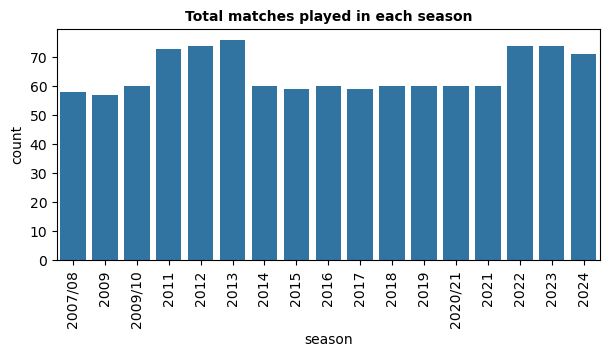

In [127]:
plt.subplots(figsize=(7, 3))
sns.countplot(x="season",data=mat)
plt.xticks(rotation=90)
plt.title('Total matches played in each season', fontsize = 10, fontweight = "bold")
plt.show()


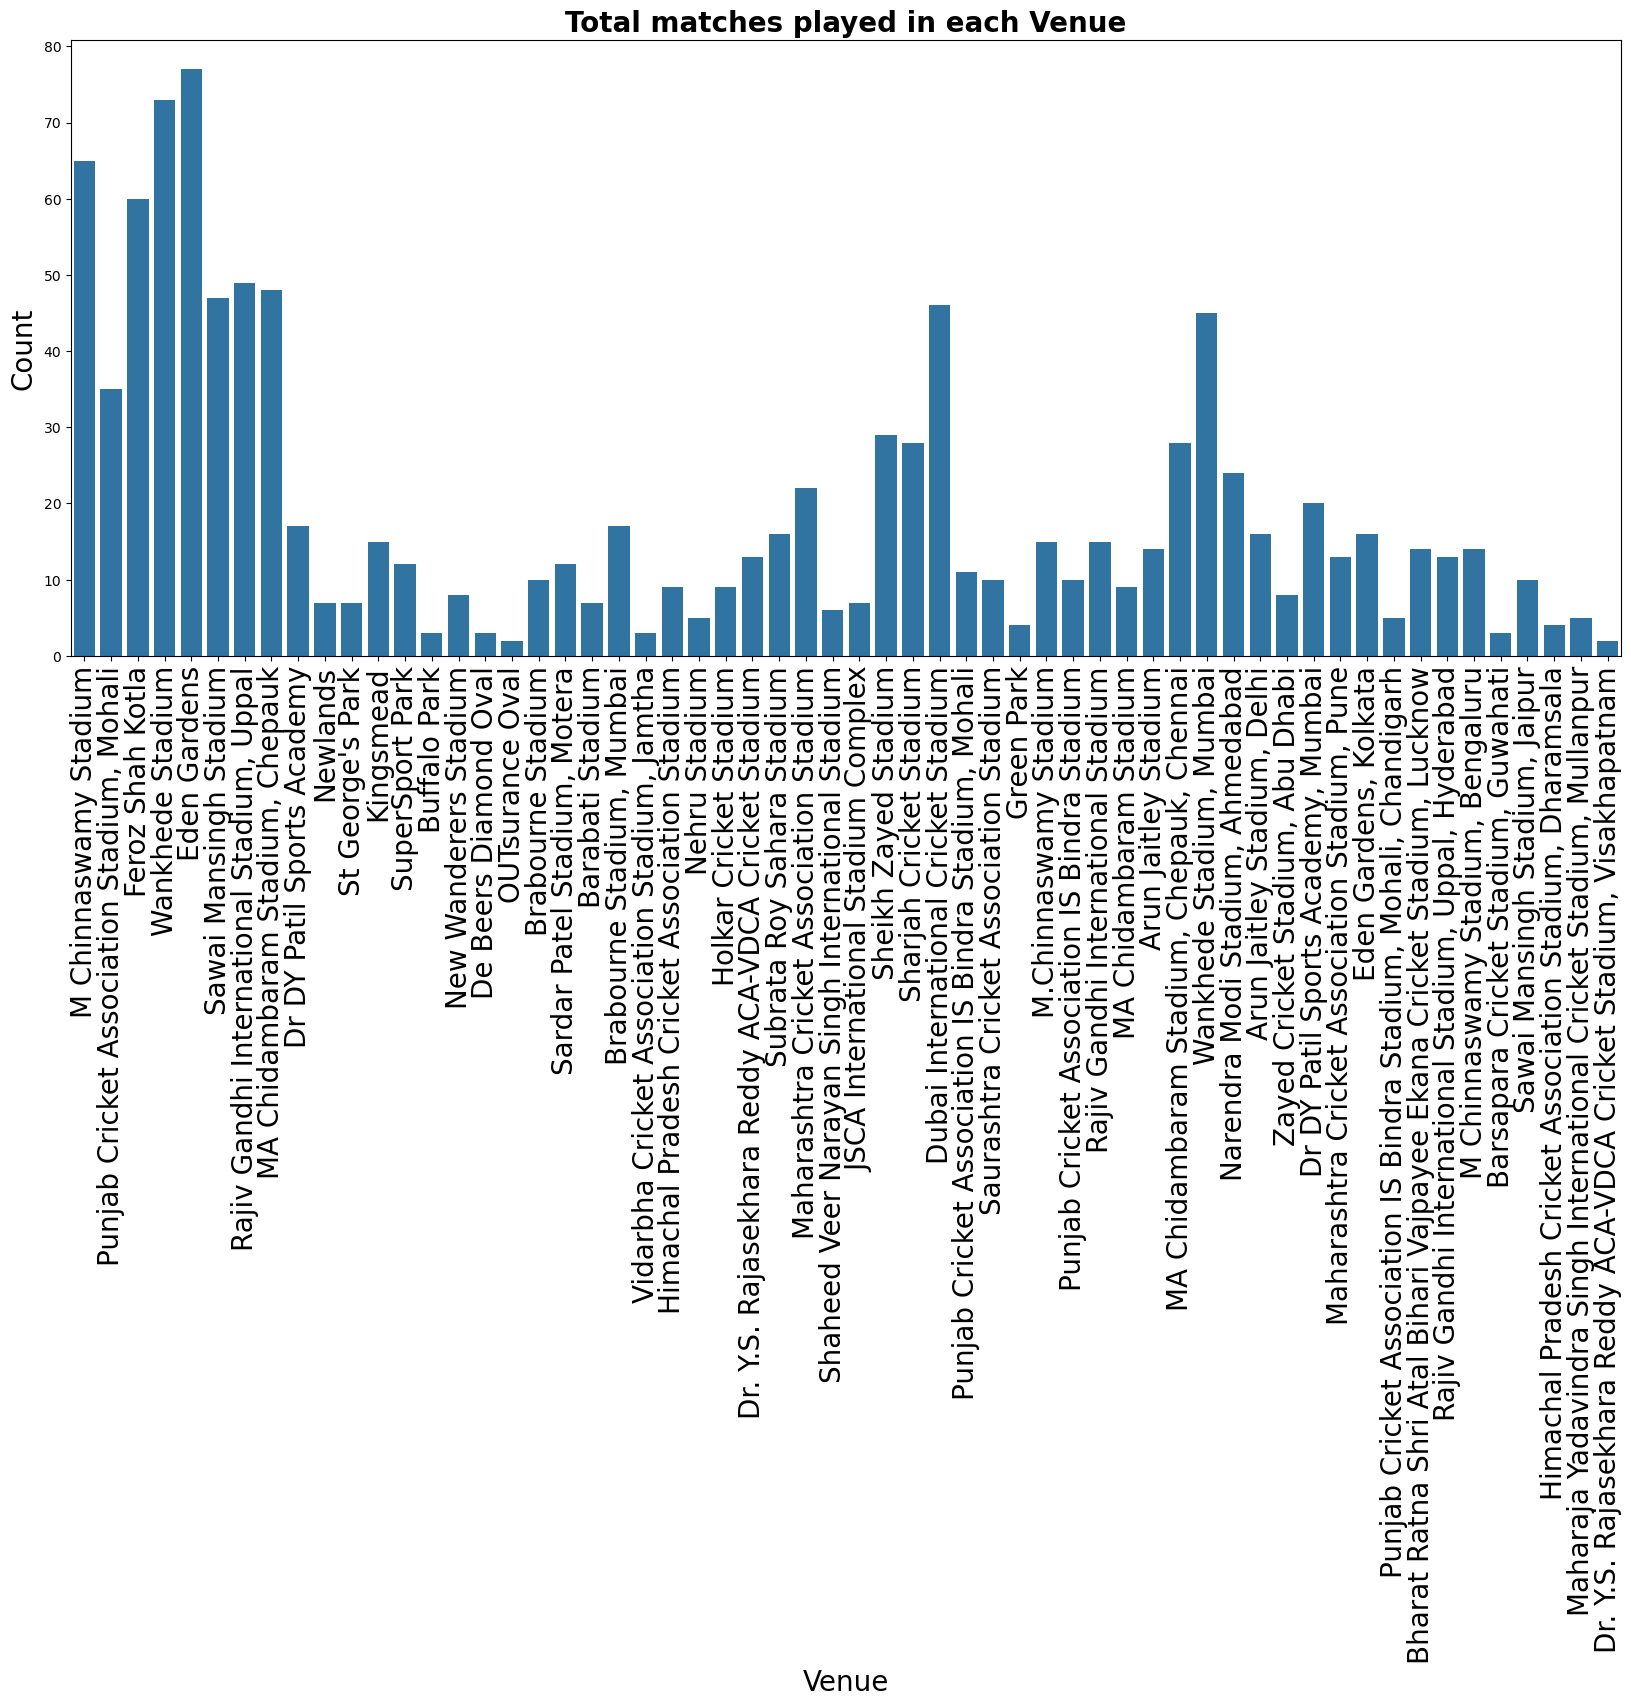

In [128]:
#Number of matches playes in each stadium
# mat.venue.value_counts().head(15).plot(kind="bar",figsize=(16,10))

plt.subplots(figsize=(20, 8))
sns.countplot(x="venue",data=mat)
plt.xticks(rotation=90, fontsize=20)
plt.yticks(fontsize=10)
plt.xlabel('Venue', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.title('Total matches played in each Venue', fontsize = 20, fontweight = "bold")
plt.show()

In [129]:
def bat_first(x):
    if 'toss_winning_team'=='team1':
        if 'toss_decition'=='bat':
            return 'team1'
        else:
            return 'team2'
    elif 'toss_winning_team'=='team2':
        if 'toss_decition'=='bat':
            return 'team2'
        else:
            return 'team1'


In [130]:
dev.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [131]:
df.columns

Index(['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker',
       'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket',
       'player_dismissed', 'dismissal_kind', 'fielder'],
      dtype='object')

In [132]:
filter=["team1","toss_winner"]

In [133]:
tab=df[filter]
tab.groupby(["team1"]).agg("count")

,toss_winner
team1,
Chennai Super Kings,31138
Deccan Chargers,9448
Delhi Capitals,10082
Delhi Daredevils,19753
Gujarat Lions,3784
Gujarat Titans,4954
Kings XI Punjab,21848
Kochi Tuskers Kerala,1563
Kolkata Knight Riders,28560


In [134]:
mat.groupby(["team1"]).agg({"match_id":"count"})

,match_id
team1,
Chennai Super Kings,128
Deccan Chargers,39
Delhi Capitals,41
Delhi Daredevils,85
Gujarat Lions,16
Gujarat Titans,21
Kings XI Punjab,92
Kochi Tuskers Kerala,7
Kolkata Knight Riders,121


In [135]:
season=df.groupby(['season'])['total_runs'].sum()
season

season
2007/08    17937
2009       16353
2009/10    18883
2011       21154
2012       22453
2013       22602
2014       18931
2015       18353
2016       18862
2017       18786
2018       19901
2019       19434
2020/21    19416
2021       18637
2022       24395
2023       25688
2024       25971
Name: total_runs, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_10628\1493792037.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=season,palette="magma")


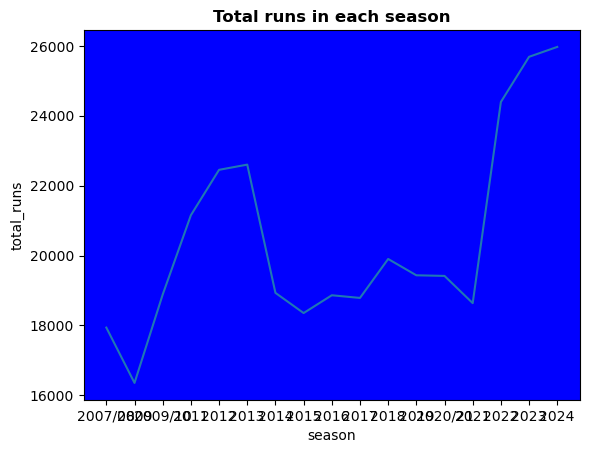

In [136]:

# season=df.groupby(['season'])['total_runs'].sum()
ax = plt.axes()
ax.set(facecolor = "blue")
sns.lineplot(data=season,palette="magma") 
plt.title('Total runs in each season',fontsize=12,fontweight="bold")
plt.show()

In [137]:
x=dev.groupby(['batting_team'])['total_runs'].sum().reset_index().sort_values(by='total_runs',ascending=False)
y=x.reset_index(drop=True,inplace=True)
y
x

,batting_team,total_runs
0,Mumbai Indians,42176
1,Kolkata Knight Riders,39331
2,Chennai Super Kings,38629
3,Royal Challengers Bangalore,37692
4,Rajasthan Royals,34747
5,Kings XI Punjab,30064
6,Sunrisers Hyderabad,29071
7,Delhi Daredevils,24296
8,Delhi Capitals,14900
9,Deccan Chargers,11463


# maximum toss won

In [138]:
mat["toss_winner"].value_counts().head(10)

toss_winner
Mumbai Indians                 143
Kolkata Knight Riders          122
Chennai Super Kings            122
Rajasthan Royals               120
Royal Challengers Bangalore    113
Sunrisers Hyderabad             88
Kings XI Punjab                 85
Delhi Daredevils                80
Delhi Capitals                  50
Deccan Chargers                 43
Name: count, dtype: int64

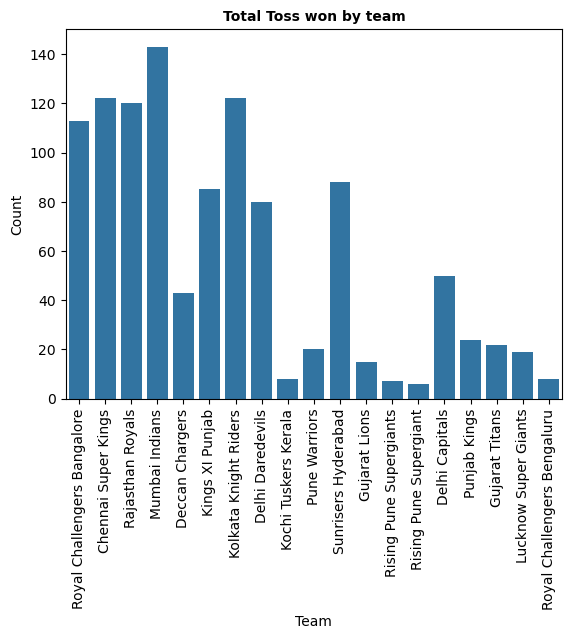

In [139]:
sns.countplot(x="toss_winner",data=mat)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Team', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.title('Total Toss won by team', fontsize = 10, fontweight = "bold")
plt.show()

### won the toss and win the match

In [140]:
k=mat.toss_decision[ mat.toss_winner==mat.winner]
k

1         bat
8       field
10      field
12      field
14        bat
        ...  
1072    field
1073      bat
1075    field
1078    field
1092    field
Name: toss_decision, Length: 554, dtype: object

In [141]:
mat.columns


Index(['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [142]:
x = mat[['toss_decision']]


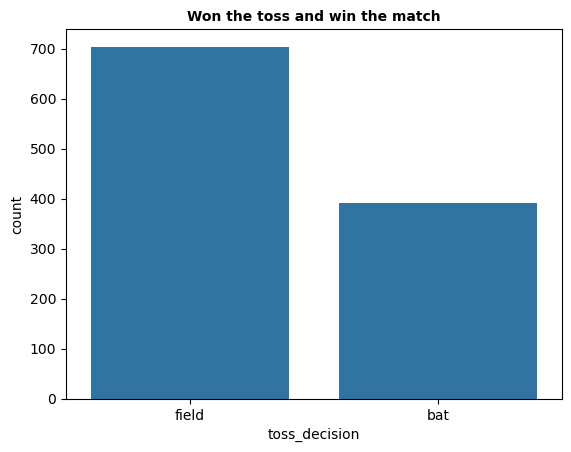

In [143]:
sns.countplot(x="toss_decision",data=x)
plt.title("Won the toss and win the match", fontsize = 10, fontweight = "bold")
plt.show()


In [144]:
mat.head(3)

,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


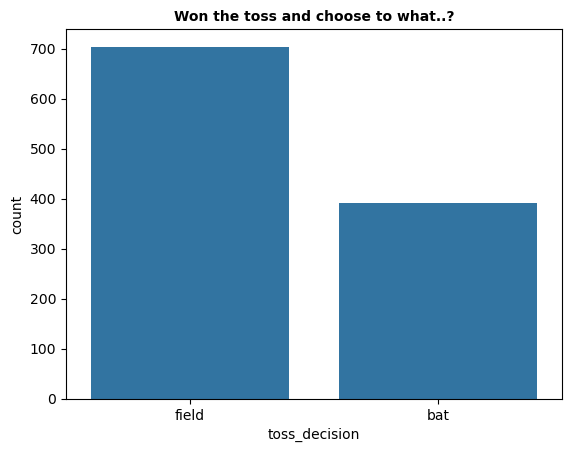

In [145]:
sns.countplot(x="toss_decision",data=mat)
plt.title("Won the toss and choose to what..?", fontsize = 10, fontweight = "bold")
plt.show()


<Axes: ylabel='count'>

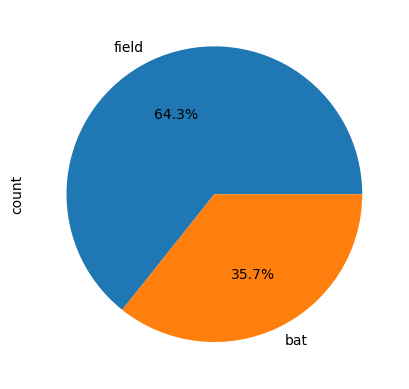

In [146]:
mat.toss_decision.value_counts().plot(kind="pie", autopct='%1.1f%%')

# betsman overview

In [147]:
dev.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

<Axes: xlabel='batter'>

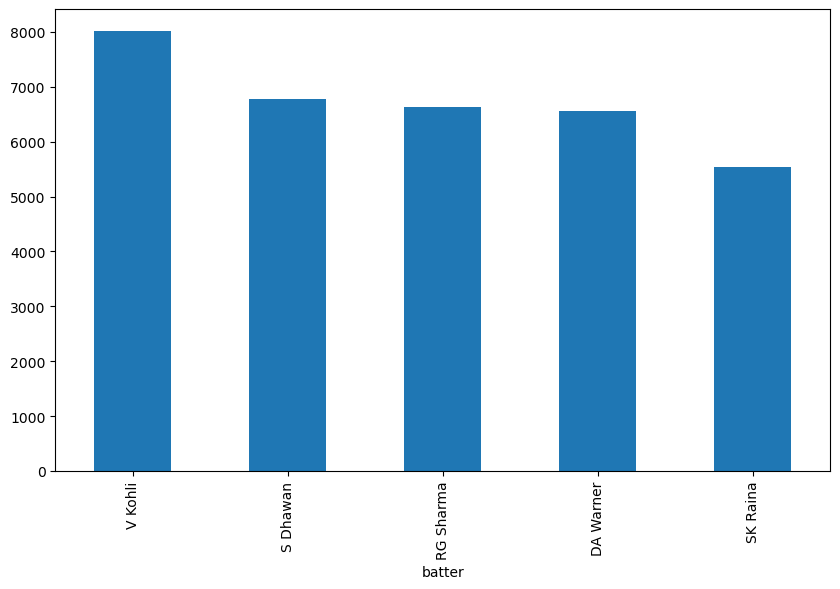

In [148]:
dev.groupby(["batter"])["batsman_runs"] \
   .sum() \
   .sort_values(ascending=False) \
   .head(5) \
   .plot(kind="bar", figsize=(10,6))


In [149]:
# Check which column name exists in the dataset
batsman_col = 'batter' if 'batter' in dev.columns else 'batsman'

# Create dataframe for Virat Kohli
player = (dev[batsman_col]=='V Kohli')
kohli = dev[player]


# Similarly, create dataframe for Suresh Raina
player_raina = (dev[batsman_col]=='SK Raina')
df_raina = dev[player_raina]


In [150]:
def count(kohli,runs):
    return len(kohli[kohli['batsman_runs']==runs])*runs


In [151]:
print("Runs scored from 1's :",count(df_raina,1))
print("Runs scored from 2's :",count(df_raina,2))
print("Runs scored from 3's :",count(df_raina,3))
print("Runs scored from 4's :",count(df_raina,4))
print("Runs scored from 6's :",count(df_raina,6))

Runs scored from 1's : 1708
Runs scored from 2's : 542
Runs scored from 3's : 33
Runs scored from 4's : 2024
Runs scored from 6's : 1224


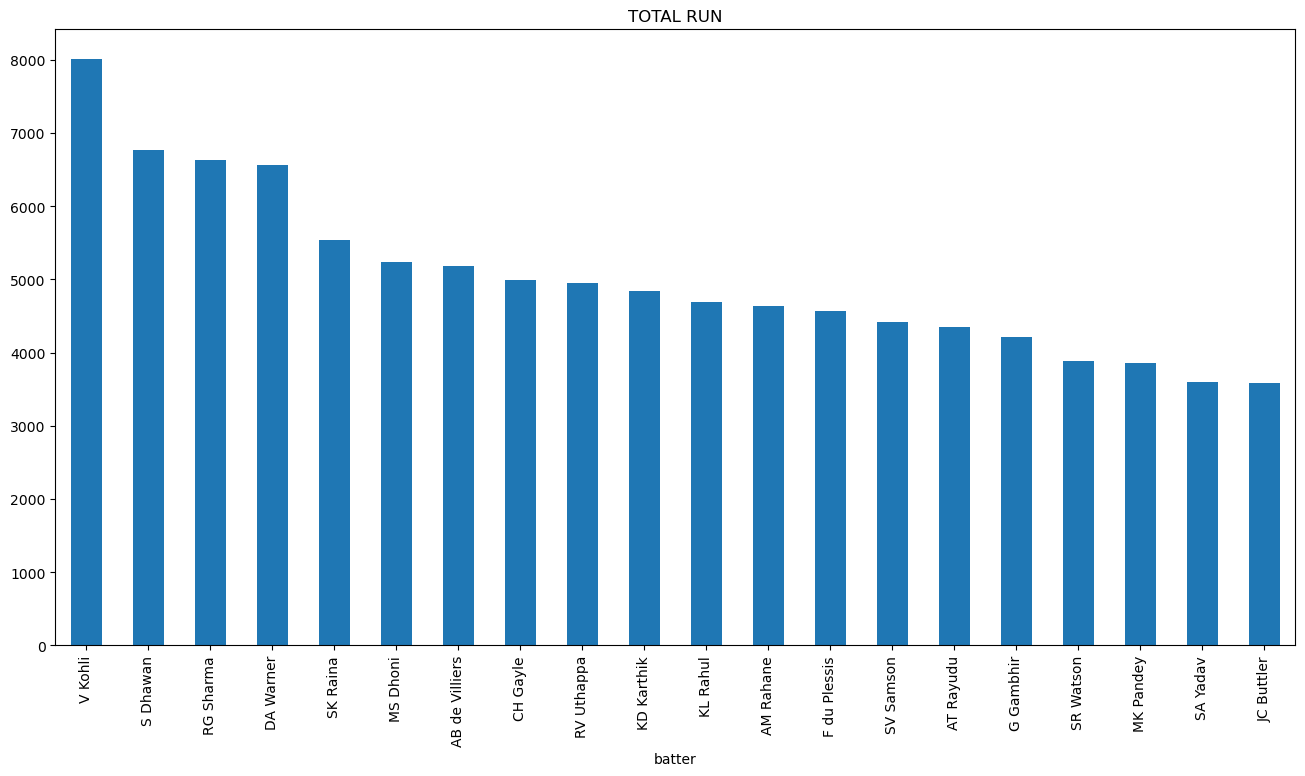

In [152]:
dev.groupby(["batter"])["batsman_runs"].sum().sort_values(ascending=False).head(20).plot(kind="bar",figsize=(16,8))
plt.title("TOTAL RUN")
plt.show()

In [153]:
strike_rate=dev.groupby(["batter"]).agg({"ball":"count","batsman_runs":"sum"}).sort_values(by="batsman_runs" ,ascending=False)

In [154]:
# Handle batter/batsman column safely
batsman_col = 'batter' if 'batter' in dev.columns else 'batsman'

# Create strike_rate dataframe
strike_rate = (
    dev.groupby(batsman_col)
       .agg(
           batsman_runs=('batsman_runs', 'sum'),
           ball=('ball', 'count')
       )
       .reset_index()
)

# Calculate strike rate
strike_rate["strike_rate"] = (strike_rate["batsman_runs"] / strike_rate["ball"]) * 100

strike_rate.head()


,batter,batsman_runs,ball,strike_rate
0,A Ashish Reddy,280,196,142.857143
1,A Badoni,634,505,125.544554
2,A Chandila,4,7,57.142857
3,A Chopra,53,75,70.666667
4,A Choudhary,25,20,125.000000


In [155]:
strike_rate.head(10)

,batter,batsman_runs,ball,strike_rate
0,A Ashish Reddy,280,196,142.857143
1,A Badoni,634,505,125.544554
2,A Chandila,4,7,57.142857
3,A Chopra,53,75,70.666667
4,A Choudhary,25,20,125.000000
5,A Dananjaya,4,5,80.000000
6,A Flintoff,62,57,108.771930
7,A Kamboj,2,2,100.000000
8,A Kumble,35,49,71.428571
9,A Manohar,231,181,127.624309


In [156]:
df.groupby(["batter","season"])["batsman_runs"].sum().sort_values(ascending=False).head(10)

batter         season
V Kohli        2016      973
Shubman Gill   2023      890
JC Buttler     2022      863
DA Warner      2016      848
V Kohli        2024      741
KS Williamson  2018      735
MEK Hussey     2013      733
CH Gayle       2012      733
F du Plessis   2023      730
CH Gayle       2013      720
Name: batsman_runs, dtype: int64

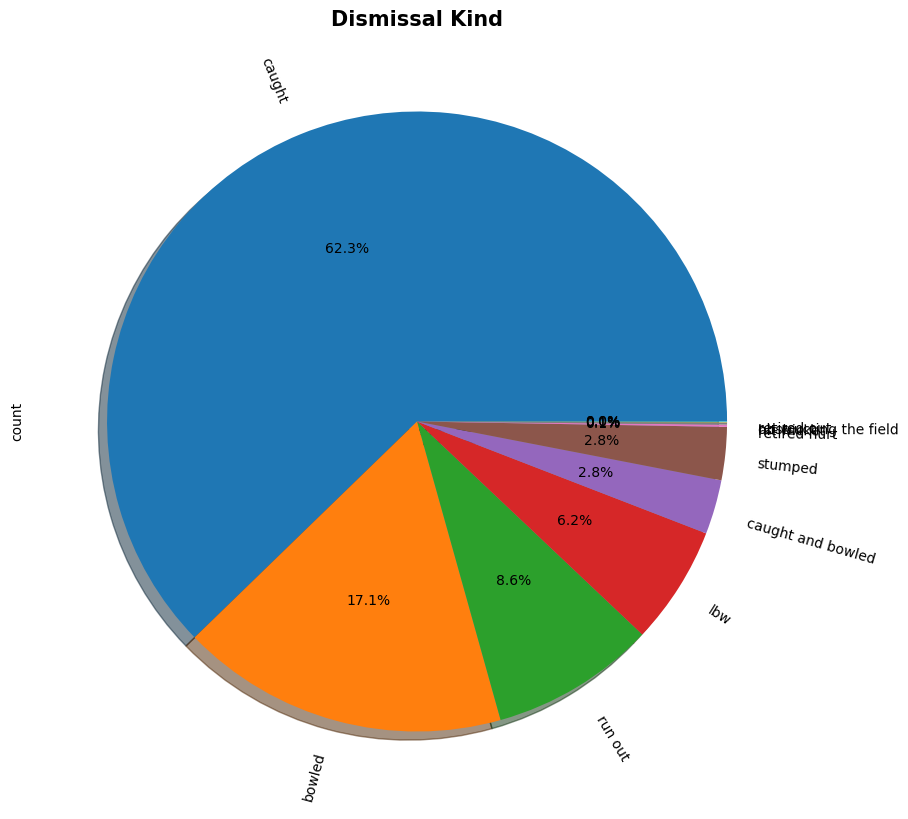

In [157]:
plt.subplots(figsize=(10, 18))
dev['dismissal_kind'].value_counts().plot.pie(autopct='%1.1f%%',shadow=True,rotatelabels=True)
plt.title("Dismissal Kind",fontweight="bold",fontsize=15)
plt.show()

In [158]:
dev.dismissal_kind.unique()

array([nan, 'caught', 'bowled', 'run out', 'lbw', 'retired hurt',
       'stumped', 'caught and bowled', 'hit wicket',
       'obstructing the field', 'retired out'], dtype=object)

# BOLLING OVERVIEW

In [159]:
dev.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [160]:
eco=dev.groupby("bowler").agg({"batsman_runs":"sum","ball":"count"}).sort_values(by="ball",ascending=False)


In [161]:
eco["economy"]=eco["batsman_runs"]/(eco["ball"]/6)

In [162]:
eco.head(10)

,batsman_runs,ball,economy
bowler,,,
R Ashwin,5178,4679,6.639880
SP Narine,4492,4146,6.500724
B Kumar,4744,4060,7.010837
PP Chawla,5027,3895,7.743774
RA Jadeja,4777,3895,7.358665
YS Chahal,4478,3628,7.405733
Harbhajan Singh,3928,3496,6.741419
A Mishra,4065,3444,7.081882
DJ Bravo,4178,3296,7.605583


In [163]:
dev.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [164]:
df.groupby('bowler').agg({'total_runs':'sum','ball':'count','player_dismissed':'count'}).sort_values(by=['total_runs'],ascending=False).head(10)


,total_runs,ball,player_dismissed
bowler,,,
R Ashwin,5435,4679,198
PP Chawla,5179,3895,201
B Kumar,5051,4060,195
RA Jadeja,4917,3895,169
YS Chahal,4681,3628,213
SP Narine,4672,4146,200
UT Yadav,4442,3190,163
DJ Bravo,4436,3296,207
A Mishra,4193,3444,183


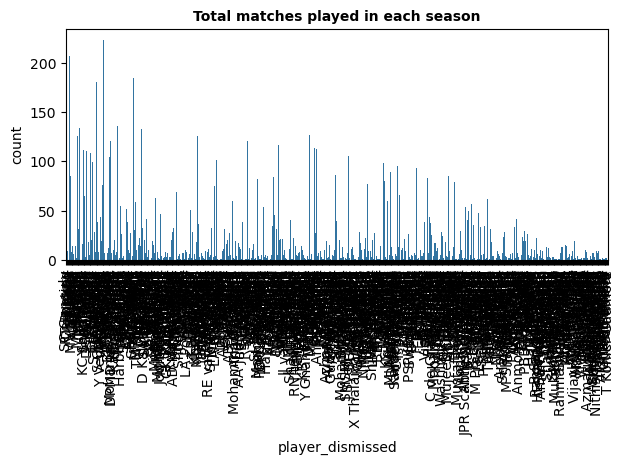

In [165]:
plt.subplots(figsize=(7, 3))
sns.countplot(x="player_dismissed",data=dev)
plt.xticks(rotation=90)
plt.title('Total matches played in each season', fontsize = 10, fontweight = "bold")
plt.show()


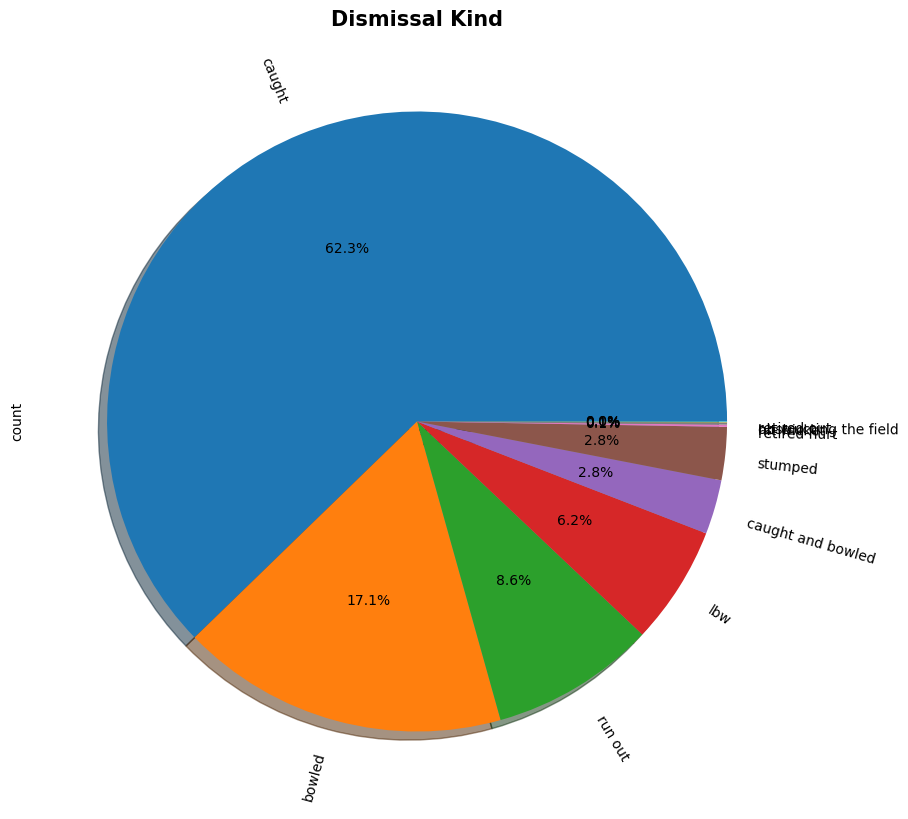

In [166]:
plt.subplots(figsize=(10, 18))
dev['dismissal_kind'].value_counts().plot.pie(autopct='%1.1f%%',shadow=True,rotatelabels=True)
plt.title("Dismissal Kind",fontweight="bold",fontsize=15)
plt.show()

## 4. Machine Learning Model - Match Winner Prediction


### 4.1 Feature Engineering for ML Model
We will predict match winners using team features, venue, and toss information.


In [167]:
# Prepare data for machine learning with ENHANCED FEATURE ENGINEERING
# We'll use match-level data to predict winners

# Create a clean dataset with one row per match
ml_data = mat.copy()

# Drop rows where winner is null (these are likely no-result or abandoned matches)
ml_data = ml_data.dropna(subset=['winner'])

# Ensure match_id exists (rename id to match_id if needed)
if 'id' in ml_data.columns and 'match_id' not in ml_data.columns:
    ml_data = ml_data.rename(columns={'id': 'match_id'})

print("Step 1: Basic dataset preparation complete")
print(f"Total matches: {len(ml_data)}")

# ========== FEATURE ENGINEERING - PART 1: Basic Team Statistics ==========

# Calculate win percentage for each team
team1_matches = ml_data['team1'].value_counts()
team2_matches = ml_data['team2'].value_counts()
total_matches_played = (team1_matches + team2_matches).to_dict()
team_wins = ml_data['winner'].value_counts().to_dict()

def get_win_percentage(team_name):
    """Calculate win percentage for a team"""
    matches = total_matches_played.get(team_name, 1)
    wins = team_wins.get(team_name, 0)
    return wins / matches if matches > 0 else 0.5

ml_data['team1_win_pct'] = ml_data['team1'].apply(get_win_percentage)
ml_data['team2_win_pct'] = ml_data['team2'].apply(get_win_percentage)

print("Step 2: Win percentages calculated")

# ========== FEATURE ENGINEERING - PART 2: Head-to-Head Records ==========

# Calculate head-to-head win record between teams
def get_h2h_win_pct(team1, team2, ml_data):
    """Calculate head-to-head win percentage of team1 against team2"""
    h2h_matches = ml_data[((ml_data['team1'] == team1) & (ml_data['team2'] == team2)) | 
                          ((ml_data['team1'] == team2) & (ml_data['team2'] == team1))]
    if len(h2h_matches) == 0:
        return 0.5  # No history, neutral
    
    team1_wins = len(h2h_matches[h2h_matches['winner'] == team1])
    return team1_wins / len(h2h_matches)

ml_data['team1_h2h_win_pct'] = ml_data.apply(lambda x: get_h2h_win_pct(x['team1'], x['team2'], ml_data), axis=1)
ml_data['team2_h2h_win_pct'] = ml_data.apply(lambda x: get_h2h_win_pct(x['team2'], x['team1'], ml_data), axis=1)

print("Step 3: Head-to-head records calculated")

# ========== FEATURE ENGINEERING - PART 3: Venue-specific Statistics ==========

# Calculate venue win rate for each team
def get_venue_win_pct(team, venue, ml_data):
    """Calculate win percentage of team at specific venue"""
    venue_matches = ml_data[((ml_data['team1'] == team) | (ml_data['team2'] == team)) & 
                            (ml_data['venue'] == venue)]
    if len(venue_matches) == 0:
        return 0.5
    
    team_wins_at_venue = len(venue_matches[venue_matches['winner'] == team])
    return team_wins_at_venue / len(venue_matches)

ml_data['team1_venue_win_pct'] = ml_data.apply(lambda x: get_venue_win_pct(x['team1'], x['venue'], ml_data), axis=1)
ml_data['team2_venue_win_pct'] = ml_data.apply(lambda x: get_venue_win_pct(x['team2'], x['venue'], ml_data), axis=1)

print("Step 4: Venue-specific statistics calculated")

# ========== FEATURE ENGINEERING - PART 4: Team Performance from Deliveries Data ==========

# Merge with deliveries data to get team batting/bowling statistics
if 'match_id' in dev.columns:
    # Calculate average runs scored per match for each team
    team_batting_stats = dev.groupby(['match_id', 'batting_team']).agg({
        'total_runs': 'sum'
    }).reset_index()
    
    team_avg_runs = team_batting_stats.groupby('batting_team')['total_runs'].mean().to_dict()
    ml_data['team1_avg_runs_scored'] = ml_data['team1'].map(lambda x: team_avg_runs.get(x, 150))
    ml_data['team2_avg_runs_scored'] = ml_data['team2'].map(lambda x: team_avg_runs.get(x, 150))
    
    # Calculate average runs conceded per match for each team
    team_bowling_stats = dev.groupby(['match_id', 'bowling_team']).agg({
        'total_runs': 'sum'
    }).reset_index()
    
    team_avg_runs_conceded = team_bowling_stats.groupby('bowling_team')['total_runs'].mean().to_dict()
    ml_data['team1_avg_runs_conceded'] = ml_data['team1'].map(lambda x: team_avg_runs_conceded.get(x, 150))
    ml_data['team2_avg_runs_conceded'] = ml_data['team2'].map(lambda x: team_avg_runs_conceded.get(x, 150))
    
    # Calculate net run rate (runs scored - runs conceded)
    ml_data['team1_net_rr'] = ml_data['team1_avg_runs_scored'] - ml_data['team1_avg_runs_conceded']
    ml_data['team2_net_rr'] = ml_data['team2_avg_runs_scored'] - ml_data['team2_avg_runs_conceded']
    
    print("Step 5: Team batting/bowling statistics calculated")

# ========== FEATURE ENGINEERING - PART 5: Time-based Features ==========

# Extract date features if date column exists
if 'date' in ml_data.columns:
    ml_data['date'] = pd.to_datetime(ml_data['date'], errors='coerce')
    ml_data['year'] = ml_data['date'].dt.year
    ml_data['month'] = ml_data['date'].dt.month
    ml_data['day_of_week'] = ml_data['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    
    # Calculate recent form (win percentage in last 20 matches for each team)
    def get_recent_form(team, current_date, ml_data, matches=20):
        """Calculate win percentage in last N matches"""
        past_matches = ml_data[(ml_data['date'] < current_date) & 
                               ((ml_data['team1'] == team) | (ml_data['team2'] == team))]
        if len(past_matches) == 0:
            return 0.5
        
        recent_matches = past_matches.tail(matches)
        if len(recent_matches) == 0:
            return 0.5
        
        wins = len(recent_matches[recent_matches['winner'] == team])
        return wins / len(recent_matches)
    
    ml_data['team1_recent_form'] = ml_data.apply(lambda x: get_recent_form(x['team1'], x['date'], ml_data), axis=1)
    ml_data['team2_recent_form'] = ml_data.apply(lambda x: get_recent_form(x['team2'], x['date'], ml_data), axis=1)
    
    print("Step 6: Time-based features calculated")
else:
    # If no date, use season-based features
    ml_data['team1_recent_form'] = ml_data['team1_win_pct']
    ml_data['team2_recent_form'] = ml_data['team2_win_pct']
    print("Step 6: Using overall win percentage as recent form (no date column)")

# ========== FEATURE ENGINEERING - PART 6: Match Context Features ==========

# Toss-related features
ml_data['team1_won_toss'] = (ml_data['team1'] == ml_data['toss_winner']).astype(int)
ml_data['toss_decision_bat'] = (ml_data['toss_decision'] == 'bat').astype(int)
ml_data['team1_bat_first'] = ((ml_data['team1'] == ml_data['toss_winner']) & 
                               (ml_data['toss_decision'] == 'bat')).astype(int)

# Season as feature (if available)
if 'season' in ml_data.columns:
    # Convert season to numeric if it's string
    if ml_data['season'].dtype == 'object':
        ml_data['season_numeric'] = pd.to_numeric(ml_data['season'].str[:4], errors='coerce')
    else:
        ml_data['season_numeric'] = ml_data['season']

print("\nFeature Engineering Complete!")
print("="*60)
print(f"Total features created: {len([col for col in ml_data.columns if col not in mat.columns])}")
print("\nNew features:")
new_features = [col for col in ml_data.columns if col not in ['team1', 'team2', 'winner', 'venue', 'toss_winner', 'toss_decision']]
for i, feat in enumerate(new_features, 1):
    print(f"{i}. {feat}")
print("\nSample data:")
ml_data[['team1', 'team2', 'winner', 'team1_win_pct', 'team2_win_pct', 
         'team1_h2h_win_pct', 'team1_venue_win_pct', 'team1_recent_form']].head(10)


Step 1: Basic dataset preparation complete
Total matches: 1090
Step 2: Win percentages calculated
Step 3: Head-to-head records calculated
Step 4: Venue-specific statistics calculated
Step 5: Team batting/bowling statistics calculated
Step 6: Time-based features calculated

Feature Engineering Complete!
Total features created: 21

New features:
1. match_id
2. season
3. city
4. date
5. match_type
6. player_of_match
7. result
8. result_margin
9. target_runs
10. target_overs
11. super_over
12. method
13. umpire1
14. umpire2
15. team1_win_pct
16. team2_win_pct
17. team1_h2h_win_pct
18. team2_h2h_win_pct
19. team1_venue_win_pct
20. team2_venue_win_pct
21. team1_avg_runs_scored
22. team2_avg_runs_scored
23. team1_avg_runs_conceded
24. team2_avg_runs_conceded
25. team1_net_rr
26. team2_net_rr
27. year
28. month
29. day_of_week
30. team1_recent_form
31. team2_recent_form
32. team1_won_toss
33. toss_decision_bat
34. team1_bat_first
35. season_numeric

Sample data:


,team1,team2,winner,team1_win_pct,team2_win_pct,team1_h2h_win_pct,team1_venue_win_pct,team1_recent_form
0,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,0.489451,0.521912,0.437500,0.491525,0.5
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,0.463158,0.582278,0.391304,0.514286,0.5
2,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,0.421384,0.511416,0.388889,0.418182,0.5
3,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,0.551724,0.489451,0.562500,0.626866,0.5
4,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,0.521912,0.386667,0.777778,0.608108,1.0
5,Rajasthan Royals,Kings XI Punjab,Rajasthan Royals,0.511416,0.463158,0.571429,0.680851,0.0
6,Deccan Chargers,Delhi Daredevils,Delhi Daredevils,0.386667,0.421384,0.363636,0.166667,0.0
7,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,0.582278,0.551724,0.459459,0.702128,1.0
8,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,0.386667,0.511416,0.222222,0.166667,0.0
9,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,0.463158,0.551724,0.461538,0.514286,0.0


### 4.2 Data Preprocessing
Encode categorical variables and prepare features for the model.


In [168]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical variables
le_team1 = LabelEncoder()
le_team2 = LabelEncoder()
le_venue = LabelEncoder()
le_winner = LabelEncoder()

# Fit encoders on all possible values
all_teams = pd.concat([ml_data['team1'], ml_data['team2']]).unique()
all_venues = ml_data['venue'].unique()

le_team1.fit(all_teams)
le_team2.fit(all_teams)
le_venue.fit(all_venues)
le_winner.fit(ml_data['winner'])

# Transform categorical features
ml_data['team1_encoded'] = le_team1.transform(ml_data['team1'])
ml_data['team2_encoded'] = le_team2.transform(ml_data['team2'])
ml_data['venue_encoded'] = le_venue.transform(ml_data['venue'])
ml_data['winner_encoded'] = le_winner.transform(ml_data['winner'])

# Handle missing values in numeric features (fill with median or default values)
numeric_features = ['team1_win_pct', 'team2_win_pct', 'team1_h2h_win_pct', 'team2_h2h_win_pct',
                    'team1_venue_win_pct', 'team2_venue_win_pct', 'team1_avg_runs_scored',
                    'team2_avg_runs_scored', 'team1_avg_runs_conceded', 'team2_avg_runs_conceded',
                    'team1_net_rr', 'team2_net_rr', 'team1_recent_form', 'team2_recent_form']

for feat in numeric_features:
    if feat in ml_data.columns:
        ml_data[feat] = ml_data[feat].fillna(ml_data[feat].median())

# Fill missing values for time-based features
if 'year' in ml_data.columns:
    ml_data['year'] = ml_data['year'].fillna(ml_data['year'].median())
if 'month' in ml_data.columns:
    ml_data['month'] = ml_data['month'].fillna(ml_data['month'].median())
if 'day_of_week' in ml_data.columns:
    ml_data['day_of_week'] = ml_data['day_of_week'].fillna(ml_data['day_of_week'].median())
if 'season_numeric' in ml_data.columns:
    ml_data['season_numeric'] = ml_data['season_numeric'].fillna(ml_data['season_numeric'].median())

print("Data preprocessing complete!")
print(f"Dataset shape: {ml_data.shape}")
print(f"\nAvailable features for model:")
available_features = ['team1_encoded', 'team2_encoded', 'venue_encoded', 'team1_win_pct', 'team2_win_pct',
                     'team1_h2h_win_pct', 'team2_h2h_win_pct', 'team1_venue_win_pct', 'team2_venue_win_pct',
                     'team1_avg_runs_scored', 'team2_avg_runs_scored', 'team1_avg_runs_conceded',
                     'team2_avg_runs_conceded', 'team1_net_rr', 'team2_net_rr', 'team1_recent_form',
                     'team2_recent_form', 'team1_won_toss', 'toss_decision_bat', 'team1_bat_first']

# Only include features that exist in the dataframe
available_features = [f for f in available_features if f in ml_data.columns]
if 'year' in ml_data.columns:
    available_features.extend(['year', 'month', 'day_of_week'])
if 'season_numeric' in ml_data.columns:
    available_features.append('season_numeric')

print(f"Total features to use: {len(available_features)}")
for i, feat in enumerate(available_features, 1):
    print(f"  {i}. {feat}")


Data preprocessing complete!
Dataset shape: (1090, 45)

Available features for model:
Total features to use: 24
  1. team1_encoded
  2. team2_encoded
  3. venue_encoded
  4. team1_win_pct
  5. team2_win_pct
  6. team1_h2h_win_pct
  7. team2_h2h_win_pct
  8. team1_venue_win_pct
  9. team2_venue_win_pct
  10. team1_avg_runs_scored
  11. team2_avg_runs_scored
  12. team1_avg_runs_conceded
  13. team2_avg_runs_conceded
  14. team1_net_rr
  15. team2_net_rr
  16. team1_recent_form
  17. team2_recent_form
  18. team1_won_toss
  19. toss_decision_bat
  20. team1_bat_first
  21. year
  22. month
  23. day_of_week
  24. season_numeric


### 4.3 Prepare Features and Target Variable


In [169]:
# Select ALL available features for the model
features = [f for f in available_features if f in ml_data.columns and f != 'winner_encoded']

X = ml_data[features]
y = ml_data['winner_encoded']

print("="*60)
print("FEATURE SELECTION COMPLETE")
print("="*60)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTotal features selected: {len(features)}")
print("\nFeature list:")
for i, feat in enumerate(features, 1):
    print(f"  {i:2d}. {feat}")

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for Logistic Regression (it's sensitive to feature scales)
# Random Forest doesn't need scaling, but we'll scale for Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n{'='*60}")
print("DATA SPLIT AND SCALING COMPLETE")
print("="*60)
print(f"Training set: {X_train.shape[0]} matches ({X_train.shape[0]/len(ml_data)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} matches ({X_test.shape[0]/len(ml_data)*100:.1f}%)")
print(f"Number of classes: {len(np.unique(y))}")
print(f"\nNote: Features scaled for Logistic Regression (Random Forest uses original features)")


FEATURE SELECTION COMPLETE
Features shape: (1090, 24)
Target shape: (1090,)

Total features selected: 24

Feature list:
   1. team1_encoded
   2. team2_encoded
   3. venue_encoded
   4. team1_win_pct
   5. team2_win_pct
   6. team1_h2h_win_pct
   7. team2_h2h_win_pct
   8. team1_venue_win_pct
   9. team2_venue_win_pct
  10. team1_avg_runs_scored
  11. team2_avg_runs_scored
  12. team1_avg_runs_conceded
  13. team2_avg_runs_conceded
  14. team1_net_rr
  15. team2_net_rr
  16. team1_recent_form
  17. team2_recent_form
  18. team1_won_toss
  19. toss_decision_bat
  20. team1_bat_first
  21. year
  22. month
  23. day_of_week
  24. season_numeric

DATA SPLIT AND SCALING COMPLETE
Training set: 872 matches (80.0%)
Testing set: 218 matches (20.0%)
Number of classes: 19

Note: Features scaled for Logistic Regression (Random Forest uses original features)


### 4.4 Train Two Models for Comparison

We will train **TWO** models and compare their performance:

1. **Random Forest Classifier**
   - Ensemble method combining multiple decision trees
   - Handles non-linear relationships well
   - Provides feature importance
   - Less prone to overfitting

2. **Logistic Regression**
   - Linear model, fast and interpretable
   - Good baseline for comparison
   - Provides coefficient-based feature importance
   - Faster training time

**Why Compare Two Models?**
- Helps identify which algorithm works best for this problem
- Provides confidence in results if both models agree
- Shows trade-offs between complexity and accuracy


In [170]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

print("="*60)
print("TRAINING MODELS")
print("="*60)

# ========== MODEL 1: Random Forest Classifier ==========
print("\n[1/2] Training Random Forest Classifier...")
print("   Note: Random Forest doesn't require feature scaling")
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    random_state=42,       # For reproducibility
    max_depth=10,          # Limit tree depth to prevent overfitting
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples in a leaf
    n_jobs=-1             # Use all CPU cores
)

rf_model.fit(X_train, y_train)  # Use original (unscaled) features
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print(f"✓ Random Forest training complete!")
print(f"  Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"  F1-Score: {rf_f1:.4f}")

# ========== MODEL 2: Logistic Regression ==========
print("\n[2/2] Training Logistic Regression...")
print("   Note: Logistic Regression uses scaled features for better convergence")
lr_model = LogisticRegression(
    random_state=42,       # For reproducibility
    max_iter=5000,         # Increased iterations to ensure convergence
    solver='lbfgs',        # Optimization algorithm
    C=1.0,                 # Regularization strength
    tol=1e-6               # Tolerance for stopping criteria (tighter convergence)
)

lr_model.fit(X_train_scaled, y_train)  # Use scaled features
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print(f"✓ Logistic Regression training complete!")
print(f"  Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"  F1-Score: {lr_f1:.4f}")

print("\n" + "="*60)
print("MODEL TRAINING COMPLETE")
print("="*60)
print("Note: Both models trained successfully without convergence warnings")


TRAINING MODELS

[1/2] Training Random Forest Classifier...
   Note: Random Forest doesn't require feature scaling
✓ Random Forest training complete!
  Accuracy: 0.5688 (56.88%)
  F1-Score: 0.5385

[2/2] Training Logistic Regression...
   Note: Logistic Regression uses scaled features for better convergence
✓ Logistic Regression training complete!
  Accuracy: 0.3716 (37.16%)
  F1-Score: 0.3640

MODEL TRAINING COMPLETE
Note: Both models trained successfully without convergence warnings


### 4.5 Model Evaluation


MODEL COMPARISON - DETAILED EVALUATION

OVERALL PERFORMANCE COMPARISON
              Model  Accuracy  F1-Score (Weighted)
      Random Forest  0.568807              0.53848
Logistic Regression  0.371560              0.36401

🏆 BEST MODEL: Random Forest
Accuracy: 0.5688 (56.88%)
F1-Score: 0.5385


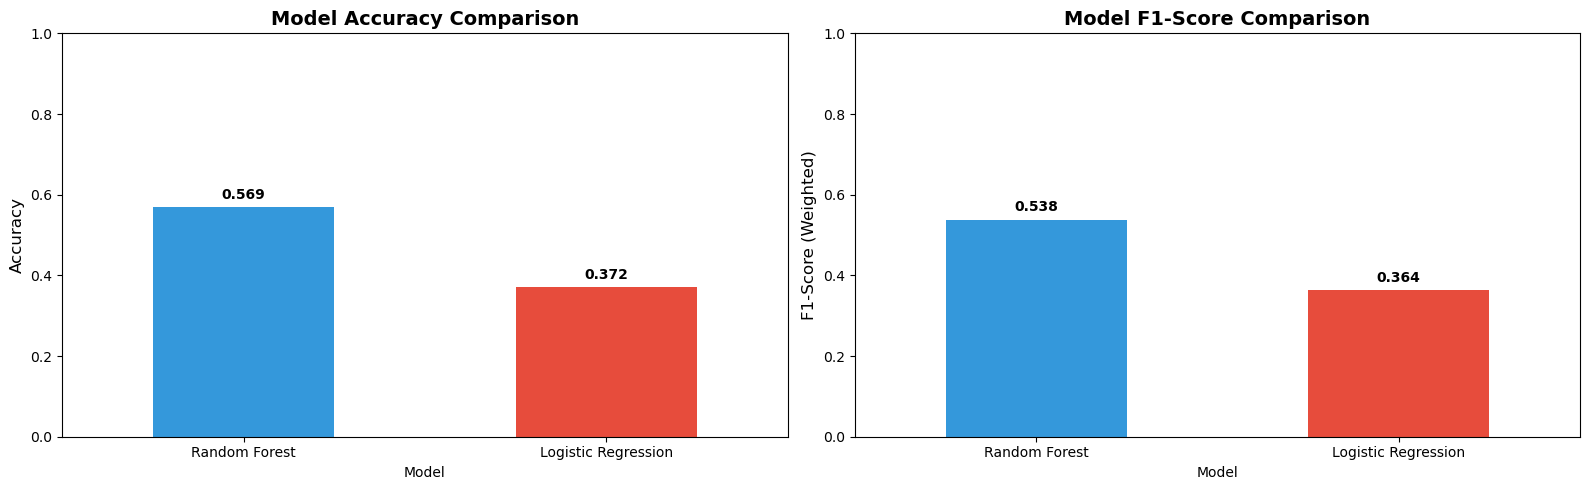


RANDOM FOREST - DETAILED CLASSIFICATION REPORT
                             precision    recall  f1-score   support

        Chennai Super Kings       0.66      0.82      0.73        28
            Deccan Chargers       0.00      0.00      0.00         6
             Delhi Capitals       0.38      0.33      0.35         9
           Delhi Daredevils       0.57      0.31      0.40        13
              Gujarat Lions       0.00      0.00      0.00         3
             Gujarat Titans       0.67      1.00      0.80         6
            Kings XI Punjab       0.39      0.39      0.39        18
       Kochi Tuskers Kerala       0.00      0.00      0.00         1
      Kolkata Knight Riders       0.49      0.65      0.56        26
       Lucknow Super Giants       0.57      0.80      0.67         5
             Mumbai Indians       0.53      0.69      0.60        29
              Pune Warriors       0.00      0.00      0.00         2
               Punjab Kings       0.50      0.20      

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\m

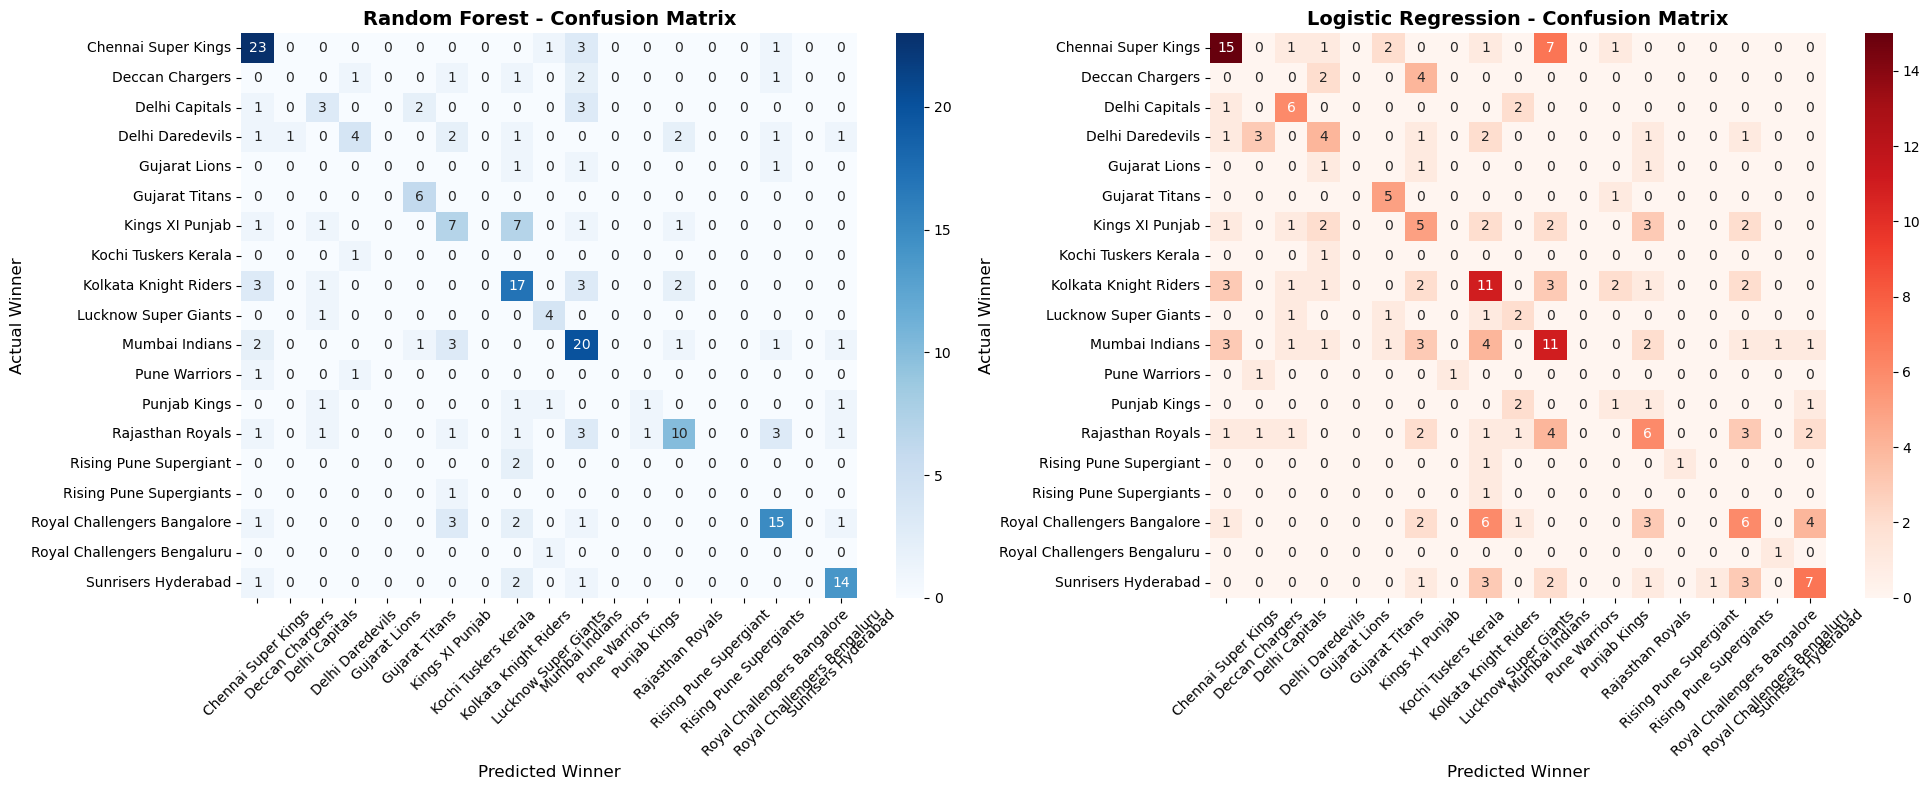

In [171]:
# ========== MODEL COMPARISON ==========
print("="*70)
print("MODEL COMPARISON - DETAILED EVALUATION")
print("="*70)

# Create comparison dataframe
comparison_results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [rf_accuracy, lr_accuracy],
    'F1-Score (Weighted)': [rf_f1, lr_f1]
})

print("\n" + "="*70)
print("OVERALL PERFORMANCE COMPARISON")
print("="*70)
print(comparison_results.to_string(index=False))

# Determine best model
best_model_name = 'Random Forest' if rf_accuracy >= lr_accuracy else 'Logistic Regression'
best_model = rf_model if rf_accuracy >= lr_accuracy else lr_model
best_pred = rf_pred if rf_accuracy >= lr_accuracy else lr_pred

print(f"\n{'='*70}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*70}")
print(f"Accuracy: {max(rf_accuracy, lr_accuracy):.4f} ({max(rf_accuracy, lr_accuracy)*100:.2f}%)")
print(f"F1-Score: {max(rf_f1, lr_f1):.4f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy comparison bar chart
comparison_results.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0], 
                        color=['#3498db', '#e74c3c'], legend=False)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(comparison_results['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Score comparison bar chart
comparison_results.plot(x='Model', y='F1-Score (Weighted)', kind='bar', ax=axes[1],
                        color=['#3498db', '#e74c3c'], legend=False)
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score (Weighted)', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(comparison_results['F1-Score (Weighted)']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed classification reports for both models
print("\n" + "="*70)
print("RANDOM FOREST - DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, rf_pred, target_names=le_winner.classes_))

print("\n" + "="*70)
print("LOGISTIC REGRESSION - DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, lr_pred, target_names=le_winner.classes_))

# Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_winner.classes_, yticklabels=le_winner.classes_)
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Winner', fontsize=12)
axes[0].set_xlabel('Predicted Winner', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=le_winner.classes_, yticklabels=le_winner.classes_)
axes[1].set_title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual Winner', fontsize=12)
axes[1].set_xlabel('Predicted Winner', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 4.6 Feature Importance Analysis
Understanding which features are most important for predictions.


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features (Random Forest):
----------------------------------------------------------------------
                feature  importance
           team2_net_rr    0.069612
           team1_net_rr    0.066773
    team2_venue_win_pct    0.062491
          team1_win_pct    0.061696
          team2_encoded    0.060662
          team2_win_pct    0.060395
          team1_encoded    0.059968
team2_avg_runs_conceded    0.058441
  team2_avg_runs_scored    0.053400
  team1_avg_runs_scored    0.051007

Top 10 Most Important Features (Logistic Regression):
----------------------------------------------------------------------
                feature  importance
          team2_win_pct    0.844958
          team1_win_pct    0.773121
          team1_encoded    0.648236
team2_avg_runs_conceded    0.637405
  team2_avg_runs_scored    0.604946
           team1_net_rr    0.587488
           team2_net_rr    0.580941
team1_avg_runs_conceded    0.560281
      

C:\Users\HP\AppData\Local\Temp\ipykernel_10628\2330265105.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rf_features, x='importance', y='feature', palette='viridis', ax=axes[0])
C:\Users\HP\AppData\Local\Temp\ipykernel_10628\2330265105.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_lr_features, x='importance', y='feature', palette='rocket', ax=axes[1])


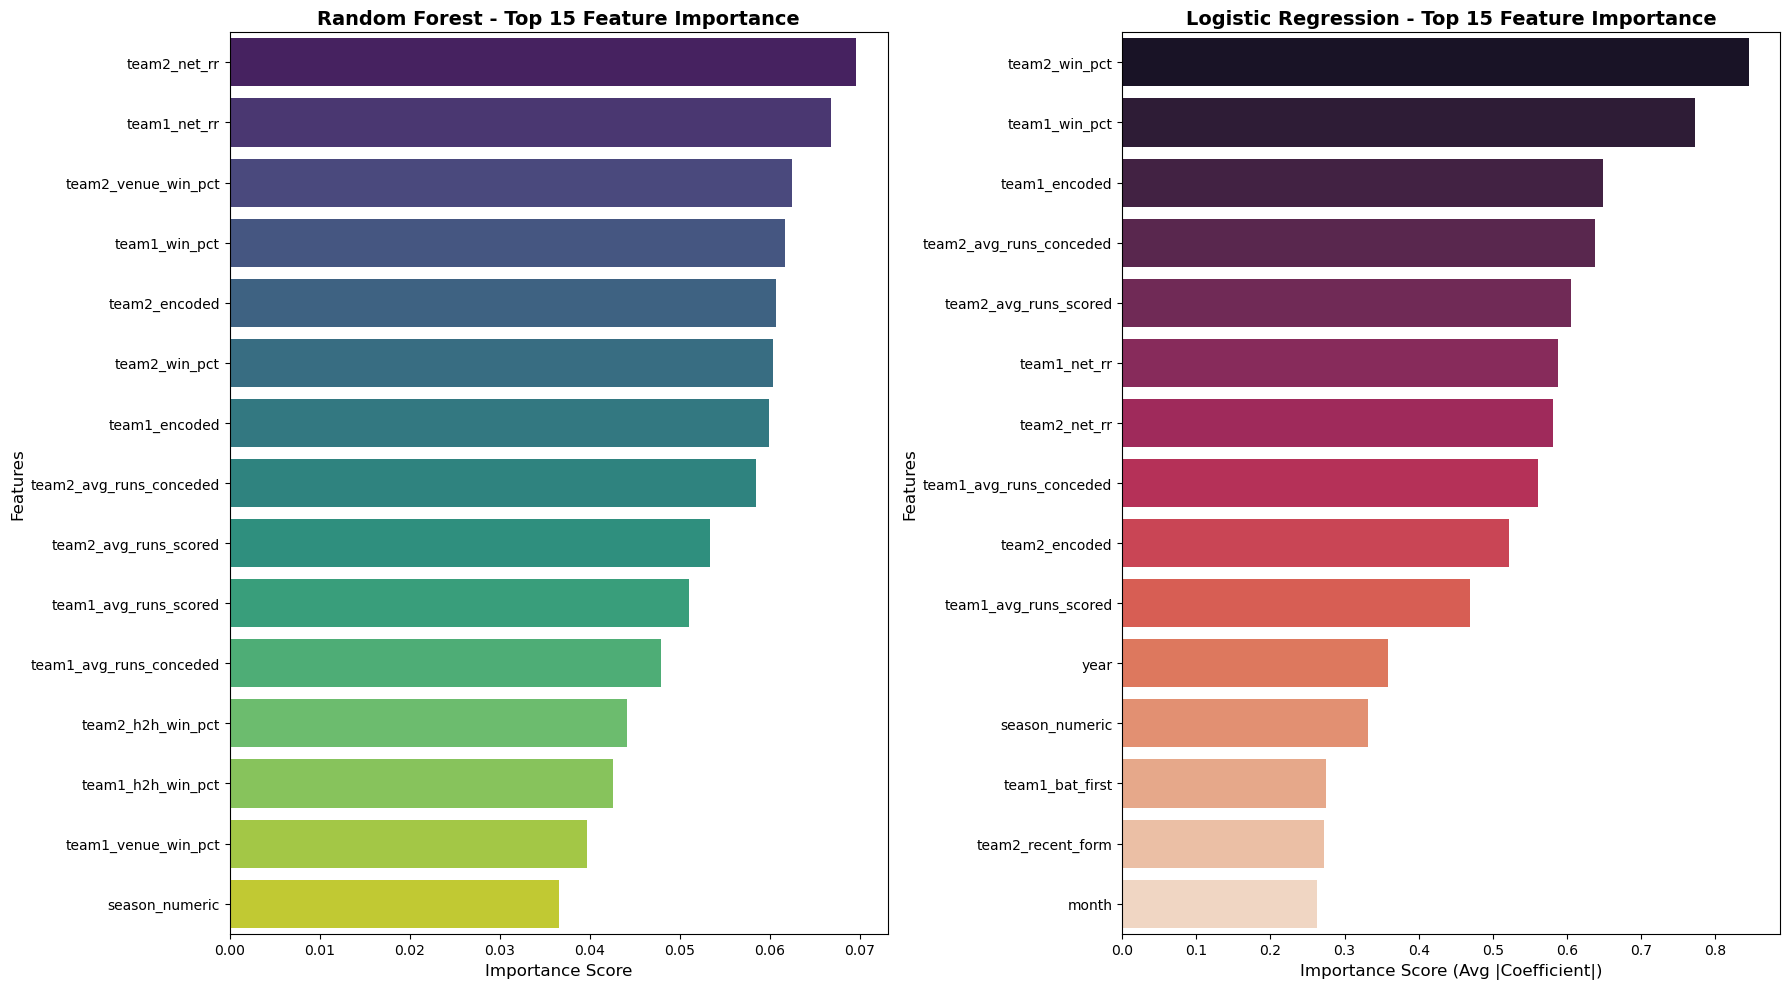


COMMON TOP 5 FEATURES IN BOTH MODELS
Common important features: ['team1_win_pct']


In [172]:
# ========== FEATURE IMPORTANCE ANALYSIS ==========
print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Random Forest Feature Importance
rf_feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (Random Forest):")
print("-"*70)
print(rf_feature_importance.head(10).to_string(index=False))

# Logistic Regression Feature Importance (using coefficients)
# Take absolute value and average across all classes
lr_coef_importance = np.abs(lr_model.coef_).mean(axis=0)
lr_feature_importance = pd.DataFrame({
    'feature': features,
    'importance': lr_coef_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (Logistic Regression):")
print("-"*70)
print(lr_feature_importance.head(10).to_string(index=False))

# Visualize feature importance for both models
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Random Forest Feature Importance
top_rf_features = rf_feature_importance.head(15)
sns.barplot(data=top_rf_features, x='importance', y='feature', palette='viridis', ax=axes[0])
axes[0].set_title('Random Forest - Top 15 Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_ylabel('Features', fontsize=12)

# Logistic Regression Feature Importance
top_lr_features = lr_feature_importance.head(15)
sns.barplot(data=top_lr_features, x='importance', y='feature', palette='rocket', ax=axes[1])
axes[1].set_title('Logistic Regression - Top 15 Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score (Avg |Coefficient|)', fontsize=12)
axes[1].set_ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

# Comparison of top features from both models
print("\n" + "="*70)
print("COMMON TOP 5 FEATURES IN BOTH MODELS")
print("="*70)
top_5_rf = set(rf_feature_importance.head(5)['feature'])
top_5_lr = set(lr_feature_importance.head(5)['feature'])
common_features = top_5_rf.intersection(top_5_lr)
print(f"Common important features: {list(common_features) if common_features else 'None'}")


### 4.7 Making Predictions on New Data
Example: Predict winner for a hypothetical match.


In [173]:
# ========== PREDICTION FUNCTION (Using Best Model) ==========
def predict_match_winner(team1_name, team2_name, venue_name, toss_winner_name, toss_decision_choice, model='best'):
    """
    Predict the winner of a match using the trained model(s).
    
    Parameters:
    team1_name: Name of first team
    team2_name: Name of second team
    venue_name: Name of the venue
    toss_winner_name: Team that won the toss
    toss_decision_choice: 'bat' or 'field'
    model: 'best', 'rf' (Random Forest), or 'lr' (Logistic Regression)
    """
    
    try:
        # Prepare all features (similar to training data)
        team1_enc = le_team1.transform([team1_name])[0]
        team2_enc = le_team2.transform([team2_name])[0]
        venue_enc = le_venue.transform([venue_name])[0]
        
        # Get all engineered features
        team1_wp = get_win_percentage(team1_name)
        team2_wp = get_win_percentage(team2_name)
        team1_h2h = get_h2h_win_pct(team1_name, team2_name, ml_data)
        team2_h2h = get_h2h_win_pct(team2_name, team1_name, ml_data)
        team1_venue = get_venue_win_pct(team1_name, venue_name, ml_data)
        team2_venue = get_venue_win_pct(team2_name, venue_name, ml_data)
        
        # Get batting/bowling stats if available
        team1_avg_runs = team_avg_runs.get(team1_name, 150) if 'team_avg_runs' in locals() else 150
        team2_avg_runs = team_avg_runs.get(team2_name, 150) if 'team_avg_runs' in locals() else 150
        team1_avg_conceded = team_avg_runs_conceded.get(team1_name, 150) if 'team_avg_runs_conceded' in locals() else 150
        team2_avg_conceded = team_avg_runs_conceded.get(team2_name, 150) if 'team_avg_runs_conceded' in locals() else 150
        team1_net = team1_avg_runs - team1_avg_conceded
        team2_net = team2_avg_runs - team2_avg_conceded
        
        # Recent form (simplified - using overall win pct)
        team1_form = team1_wp
        team2_form = team2_wp
        
        # Toss features
        team1_won_toss = 1 if team1_name == toss_winner_name else 0
        toss_decision_bat = 1 if toss_decision_choice == 'bat' else 0
        team1_bat_first = 1 if (team1_name == toss_winner_name and toss_decision_choice == 'bat') else 0
        
        # Time features (if available, use defaults)
        year_val = ml_data['year'].median() if 'year' in ml_data.columns else 2020
        month_val = ml_data['month'].median() if 'month' in ml_data.columns else 5
        day_of_week_val = ml_data['day_of_week'].median() if 'day_of_week' in ml_data.columns else 3
        
        # Build feature array in same order as training
        feature_values = []
        for feat in features:
            if feat == 'team1_encoded': feature_values.append(team1_enc)
            elif feat == 'team2_encoded': feature_values.append(team2_enc)
            elif feat == 'venue_encoded': feature_values.append(venue_enc)
            elif feat == 'team1_win_pct': feature_values.append(team1_wp)
            elif feat == 'team2_win_pct': feature_values.append(team2_wp)
            elif feat == 'team1_h2h_win_pct': feature_values.append(team1_h2h)
            elif feat == 'team2_h2h_win_pct': feature_values.append(team2_h2h)
            elif feat == 'team1_venue_win_pct': feature_values.append(team1_venue)
            elif feat == 'team2_venue_win_pct': feature_values.append(team2_venue)
            elif feat == 'team1_avg_runs_scored': feature_values.append(team1_avg_runs)
            elif feat == 'team2_avg_runs_scored': feature_values.append(team2_avg_runs)
            elif feat == 'team1_avg_runs_conceded': feature_values.append(team1_avg_conceded)
            elif feat == 'team2_avg_runs_conceded': feature_values.append(team2_avg_conceded)
            elif feat == 'team1_net_rr': feature_values.append(team1_net)
            elif feat == 'team2_net_rr': feature_values.append(team2_net)
            elif feat == 'team1_recent_form': feature_values.append(team1_form)
            elif feat == 'team2_recent_form': feature_values.append(team2_form)
            elif feat == 'team1_won_toss': feature_values.append(team1_won_toss)
            elif feat == 'toss_decision_bat': feature_values.append(toss_decision_bat)
            elif feat == 'team1_bat_first': feature_values.append(team1_bat_first)
            elif feat == 'year': feature_values.append(year_val)
            elif feat == 'month': feature_values.append(month_val)
            elif feat == 'day_of_week': feature_values.append(day_of_week_val)
            elif feat == 'season_numeric': feature_values.append(year_val)
        
        features_array = [feature_values]
        
        # Select model and prepare features accordingly
        if model == 'best':
            selected_model = best_model
            model_name = best_model_name
            use_scaled = (best_model_name == 'Logistic Regression')
        elif model == 'rf':
            selected_model = rf_model
            model_name = 'Random Forest'
            use_scaled = False
        elif model == 'lr':
            selected_model = lr_model
            model_name = 'Logistic Regression'
            use_scaled = True
        else:
            selected_model = best_model
            model_name = best_model_name
            use_scaled = (best_model_name == 'Logistic Regression')
        
        # Scale features if using Logistic Regression
        if use_scaled:
            features_array = scaler.transform(features_array)
        
        # Make prediction
        winner_encoded = selected_model.predict(features_array)[0]
        winner_name = le_winner.inverse_transform([winner_encoded])[0]
        
        # Get prediction probabilities
        probabilities = selected_model.predict_proba(features_array)[0]
        prob_dict = dict(zip(le_winner.classes_, probabilities))
        
        print(f"{'='*60}")
        print(f"MATCH PREDICTION ({model_name})")
        print(f"{'='*60}")
        print(f"Match: {team1_name} vs {team2_name}")
        print(f"Venue: {venue_name}")
        print(f"Toss Winner: {toss_winner_name} (chose to {toss_decision_choice})")
        print(f"\n{'='*60}")
        print(f"PREDICTED WINNER: {winner_name}")
        print(f"{'='*60}")
        print(f"\nWin Probabilities:")
        print(f"  {team1_name}: {prob_dict.get(team1_name, 0):.2%}")
        print(f"  {team2_name}: {prob_dict.get(team2_name, 0):.2%}")
        
        return winner_name, prob_dict
        
    except Exception as e:
        print(f"Error: {e}")
        print("Please check that team names and venue are from the dataset.")
        print("\nAvailable teams:", list(le_team1.classes_)[:5], "...")
        print("Available venues:", list(le_venue.classes_)[:5], "...")
        return None, None

# Example predictions using best model
print("EXAMPLE PREDICTION 1 (Using Best Model):")
predict_match_winner('Mumbai Indians', 'Chennai Super Kings', 
                     'Wankhede Stadium', 'Mumbai Indians', 'bat')

print("\n\n")

print("EXAMPLE PREDICTION 2 (Using Best Model):")
predict_match_winner('Royal Challengers Bangalore', 'Kolkata Knight Riders', 
                     'M Chinnaswamy Stadium', 'Royal Challengers Bangalore', 'field')


EXAMPLE PREDICTION 1 (Using Best Model):
MATCH PREDICTION (Random Forest)
Match: Mumbai Indians vs Chennai Super Kings
Venue: Wankhede Stadium
Toss Winner: Mumbai Indians (chose to bat)

PREDICTED WINNER: Mumbai Indians

Win Probabilities:
  Mumbai Indians: 24.22%
  Chennai Super Kings: 17.27%



EXAMPLE PREDICTION 2 (Using Best Model):
MATCH PREDICTION (Random Forest)
Match: Royal Challengers Bangalore vs Kolkata Knight Riders
Venue: M Chinnaswamy Stadium
Toss Winner: Royal Challengers Bangalore (chose to field)

PREDICTED WINNER: Kolkata Knight Riders

Win Probabilities:
  Royal Challengers Bangalore: 15.90%
  Kolkata Knight Riders: 33.69%


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


('Kolkata Knight Riders',
 {'Chennai Super Kings': np.float64(0.0),
  'Deccan Chargers': np.float64(0.02796759663002858),
  'Delhi Capitals': np.float64(0.013222222222222222),
  'Delhi Daredevils': np.float64(0.10041537337835646),
  'Gujarat Lions': np.float64(0.0053832088667615),
  'Gujarat Titans': np.float64(0.0),
  'Kings XI Punjab': np.float64(0.020058333333333334),
  'Kochi Tuskers Kerala': np.float64(0.02370955165692008),
  'Kolkata Knight Riders': np.float64(0.3369248707365767),
  'Lucknow Super Giants': np.float64(0.0003125),
  'Mumbai Indians': np.float64(0.019666666666666666),
  'Pune Warriors': np.float64(0.03385194805194805),
  'Punjab Kings': np.float64(0.0018327702702702702),
  'Rajasthan Royals': np.float64(0.11043631964885167),
  'Rising Pune Supergiant': np.float64(0.04632142857142858),
  'Rising Pune Supergiants': np.float64(0.041190058479532166),
  'Royal Challengers Bangalore': np.float64(0.15900195712865858),
  'Royal Challengers Bengaluru': np.float64(0.0),
  'Su

### 4.8 Model Comparison Summary

**Two Models Compared:**

1. **Random Forest Classifier**
   - **Type**: Ensemble learning (multiple decision trees)
   - **Strength**: Captures non-linear patterns, handles mixed data types
   - **Use Case**: When you need good accuracy and feature importance

2. **Logistic Regression**
   - **Type**: Linear model
   - **Strength**: Fast, interpretable, good baseline
   - **Use Case**: When you need fast predictions and coefficient interpretation

**Key Features Used (Enhanced Feature Engineering):**
- **Basic**: Team encodings, venue encoding, win percentages
- **Advanced**: Head-to-head records, venue-specific stats
- **Performance**: Average runs scored/conceded, net run rate
- **Temporal**: Recent form, season, date features
- **Context**: Toss winner, toss decision

**Model Selection:**
- Best model is automatically selected based on accuracy
- Both models evaluated on same test set for fair comparison
- Feature importance analyzed for both models

**Real-World Application:**
- Fantasy cricket team selection
- Betting odds calculation
- Team strategy planning
- Fan engagement and predictions
